# 01 Data audit

Checks the extracted keypoint data before any model is trained: split integrity, clip lengths, the
resampling repair, pose quality, the drill session confound and a no motion baseline.

Every figure and table here is also logged to ClearML (project `BadmintonPoseAnalysis/01_data`,
task `data_audit`), so the results can be checked without rerunning the notebook.

**Data.** VideoBadminton (Li et al., 2024): 18 shot classes, 1280x960 at 60 fps. Keypoints come from
YOLOv8 + ByteTrack (player tracking) and RTMPose (17 COCO joints), stored as 30 frame arrays of
(x, y, confidence).

**Inputs.** `split_manifest.csv`, `extraction_log.csv`, `keypoints_raw/`, `keypoints_smoothed/` and the
repaired `keypoints_interp/` with its log (built by `tools/repair_resampling.py`).

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, top_k_accuracy_score
from clearml import Task

REPO = os.environ.get("BADMINTON_REPO", "/workspace/badminton-honours-project")
DATA = os.environ.get("BADMINTON_DATA", "/workspace/data")
sys.path.insert(0, REPO)
import dataset as ds

MIN_NATIVE_FRAMES = 5          # train clips with fewer real frames are dropped (section 3)
DRILL_SESSION = "2023-05-02"   # ball feeding sessions added by Li et al. for rare classes
SEED = 0

JOINTS = ["nose", "l_eye", "r_eye", "l_ear", "r_ear", "l_shoulder", "r_shoulder", "l_elbow", "r_elbow",
          "l_wrist", "r_wrist", "l_hip", "r_hip", "l_knee", "r_knee", "l_ankle", "r_ankle"]
R_WRIST, L_HIP, R_HIP = 10, 11, 12

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False})
SPLIT_COLOURS = {"train": "#4c72b0", "val": "#dd8452", "test": "#55a868"}

In [2]:
task = Task.init(project_name="BadmintonPoseAnalysis/01_data", task_name="data_audit",
                 task_type=Task.TaskTypes.data_processing, reuse_last_task_id=False,
                 auto_connect_frameworks={"matplotlib": False})
task.connect({"data_root": DATA, "min_native_frames": MIN_NATIVE_FRAMES,
              "drill_session": DRILL_SESSION, "seed": SEED})
logger = task.get_logger()


def publish(fig, title):
    # same figure in the notebook and under Plots in ClearML
    logger.report_matplotlib_figure(title=title, series="data_audit", figure=fig,
                                    iteration=0, report_interactive=False)
    plt.show()


def publish_table(df, title):
    logger.report_table(title=title, series="data_audit", iteration=0, table_plot=df)
    return df

ClearML Task: created new task id=18f2712d87e4404791ed825dda0e526c
2026-09-28 08:08:07,833 - clearml.Repository Detection - WARNING - Failed accessing the jupyter server(s): []
ClearML results page: https://app.clear.ml/projects/b4a3d98306c849da8bc7f790ce039ec8/tasks/18f2712d87e4404791ed825dda0e526c/output/log


## Loading

`n_native` is the number of real frames behind each 30 frame array, read from the arrays themselves by the
repair script. It replaces `num_valid_track_frames` from the extraction log, which is stale for five clips
that were re-extracted during manual review.

In [3]:
manifest = pd.read_csv(f"{DATA}/split_manifest.csv")
log = pd.read_csv(f"{DATA}/extraction_log.csv")
repair = pd.read_csv(f"{DATA}/keypoints_interp_log.csv")

clips = (manifest
         .merge(log[["filepath", "excluded", "num_frames_total", "selection_method"]], on="filepath")
         .merge(repair[["filepath", "n_native", "mode", "max_abs_diff_vs_old_xy"]], on="filepath"))
clips["stem"] = clips["filepath"].map(lambda p: os.path.splitext(os.path.basename(p))[0])
clips["session"] = clips["stem"].str.slice(0, 19)
clips["drill"] = clips["session"].str.startswith(DRILL_SESSION)

class_names = sorted(clips["class_name"].unique())
label = {c: c.split("_", 1)[1] for c in class_names}


def load(folder, row):
    return np.load(f"{DATA}/{folder}/{row['class_name']}/{row['stem']}.npy")


excluded = clips[clips["excluded"] == True]
kept = clips[clips["excluded"] != True].reset_index(drop=True)
print(f"{len(manifest)} clips in the manifest, {len(excluded)} excluded at manual review, {len(kept)} kept")
logger.report_single_value("clips_in_manifest", len(manifest))
logger.report_single_value("clips_kept", len(kept))

7818 clips in the manifest, 4 excluded at manual review, 7814 kept


## 1. Split integrity

The split is stratified by class at clip level, 80/10/10. Li et al. describe the same 8:1:1 ratio.

In [4]:
counts = pd.crosstab(kept["class_name"], kept["split"])[["train", "val", "test"]]
counts["total"] = counts.sum(axis=1)
counts["train_share"] = (counts["train"] / counts["total"]).round(3)
counts.index = [label[c] for c in counts.index]
publish_table(counts.rename_axis("class").reset_index(), "clips per class and split")

split,class,train,val,test,total,train_share
0,Short Serve,703,88,88,879,0.800
1,Cross Court Flight,133,17,16,166,0.801
2,Lift,606,76,76,758,0.799
3,Tap Smash,87,11,11,109,0.798
4,Block,252,32,31,315,0.800
5,Drop Shot,650,81,81,812,0.800
6,Push Shot,320,40,40,400,0.800
7,Transitional Slice,98,12,13,123,0.797
8,Cut,468,58,59,585,0.800
9,Rush Shot,90,11,12,113,0.796


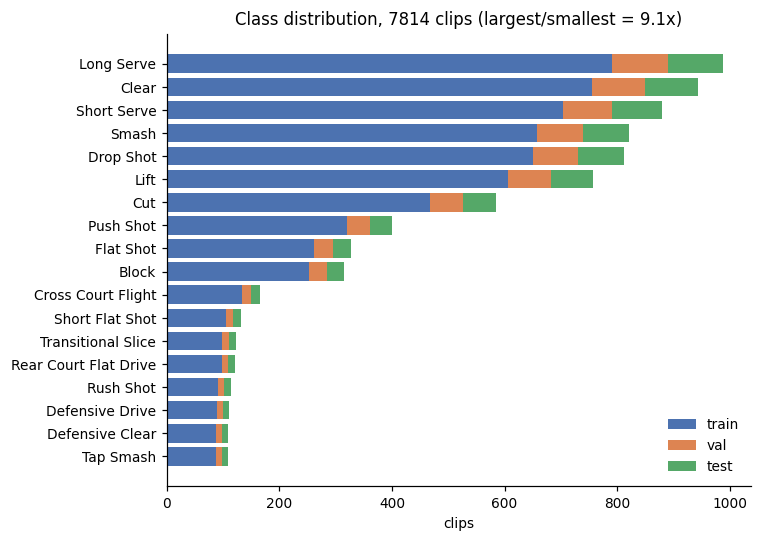

In [5]:
order = counts["total"].sort_values().index
fig, ax = plt.subplots(figsize=(7, 5))
left = np.zeros(len(order))
for split in ["train", "val", "test"]:
    ax.barh(order, counts.loc[order, split], left=left, color=SPLIT_COLOURS[split], label=split)
    left += counts.loc[order, split].to_numpy()
ratio = counts["total"].max() / counts["total"].min()
ax.set_xlabel("clips")
ax.set_title(f"Class distribution, {len(kept)} clips (largest/smallest = {ratio:.1f}x)")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
publish(fig, "class distribution")
logger.report_single_value("class_imbalance_ratio", ratio)

In [6]:
per_session = pd.crosstab(kept["session"], kept["split"])
in_all = int((per_session > 0).all(axis=1).sum())
small_test = counts[counts["test"] <= 15]
print(f"{len(per_session)} recording sessions, {in_all} appear in all three splits")
print(f"{len(small_test)} classes have 15 or fewer test clips: {', '.join(small_test.index)}")

80 recording sessions, 63 appear in all three splits
7 classes have 15 or fewer test clips: Tap Smash, Transitional Slice, Rush Shot, Defensive Clear, Defensive Drive, Rear Court Flat Drive, Short Flat Shot


Every match session appears in train, val and test, so the same players and court are seen on both sides of
the split. This matches the protocol Li et al. describe, so results stay comparable, but it is a limitation:
the test set measures generalisation to new clips, not to new players or venues.

Several classes have only 11 to 13 test clips. One clip is worth roughly 8 points of recall for those classes,
so mean class accuracy moves noticeably between seeds and small differences need multiple seeds to trust.

## 2. Clip length

Source clips are cut per shot, so their length varies with the shot itself. Every clip is resampled to 30
frames for the models, which stretches short shots and compresses long ones.

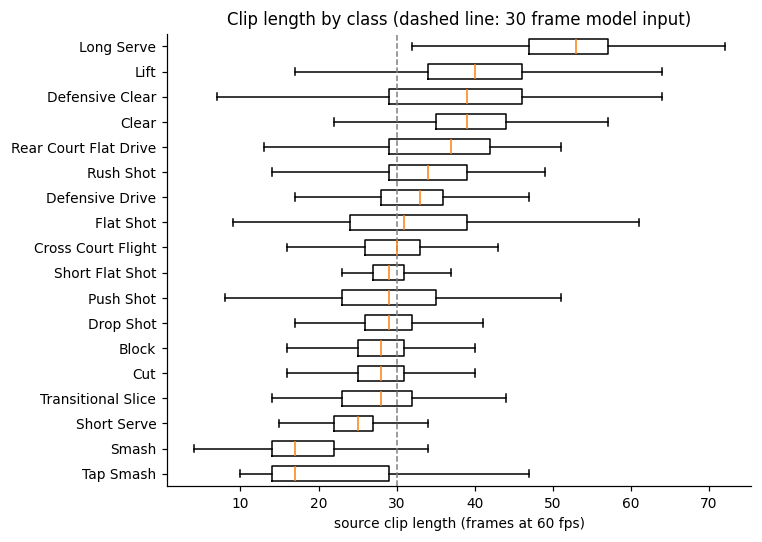

In [7]:
length_order = kept.groupby("class_name")["num_frames_total"].median().sort_values().index
fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([kept.loc[kept["class_name"] == c, "num_frames_total"] for c in length_order],
           vert=False, showfliers=False, widths=0.6)
ax.set_yticks(range(1, len(length_order) + 1), [label[c] for c in length_order])
ax.axvline(30, color="grey", ls="--", lw=1)
ax.set_xlabel("source clip length (frames at 60 fps)")
ax.set_title("Clip length by class (dashed line: 30 frame model input)")
fig.tight_layout()
publish(fig, "clip length by class")

In [8]:
rows = []
for k in [2, 5, 10, 15]:
    below = kept[kept["n_native"] < k]
    rows.append({"real frames below": k, **{s: int((below["split"] == s).sum()) for s in ["train", "val", "test"]}})
publish_table(pd.DataFrame(rows), "short clips by split")

,real frames below,train,val,test
0,2,1,1,0
1,5,4,1,1
2,10,29,2,6
3,15,300,30,34


## 3. Short clip rule

A few source clips are only 1 to 4 frames long. These are segmentation errors in the dataset rather than
tracking failures (the video itself is that short), and a clip that short carries no motion.

**Rule:** train clips with fewer than `MIN_NATIVE_FRAMES` real frames are dropped. Val and test are left
untouched, so the evaluation set stays the full 782 clips and results remain comparable with Li et al.

In [9]:
dropped = kept[(kept["split"] == "train") & (kept["n_native"] < MIN_NATIVE_FRAMES)]
publish_table(dropped[["filepath", "class_name", "n_native", "num_frames_total"]].reset_index(drop=True),
              "train clips dropped by the short clip rule")
logger.report_single_value("train_clips_dropped_short", len(dropped))
dropped[["filepath", "n_native"]]

,filepath,n_native
1360,02_Lift/2022-08-31_19-09-07_dataset_set1_096_0...,1
1543,02_Lift/2022-09-06_17-42-57_dataset_set1_117_0...,3
4168,09_Rush Shot/2022-09-06_19-07-23_dataset_set1_...,2
6434,14_Smash/2022-08-30_18-10-55_dataset_set1_088_...,4


## 4. Resampling repair

The extraction mapped each clip onto 30 slots by rounding evenly spaced positions to whole frames. For clips
shorter than 30 frames this duplicates frames, and the smoothing then ran on the duplicated sequence, so motion
looked like hold, jump, hold. The repair recovers the real frames from `keypoints_raw` (every real frame is hit
at least once by the rounding), smooths them at the native frame rate and interpolates linearly to 30.
Clips of 30 frames or more were subsampled rather than duplicated and are unchanged.

Below, the right wrist of one short clip: real frames placed at their true times, the previous array and the
repaired one.

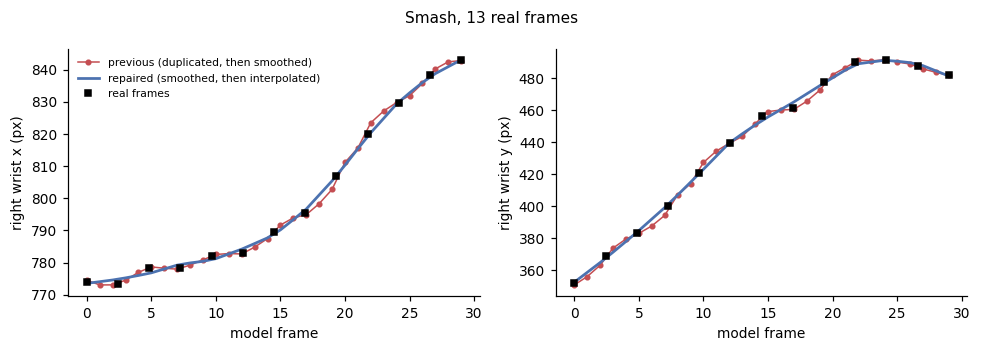

In [10]:
candidates = kept[(kept["mode"] == "interpolated") & kept["n_native"].between(12, 16)]
example = candidates.sort_values("max_abs_diff_vs_old_xy").iloc[len(candidates) // 2]
raw, old, new = (load(f, example) for f in ["keypoints_raw", "keypoints_smoothed", "keypoints_interp"])

n = int(example["n_native"])
slot_of = np.linspace(0, n - 1, 30).round().astype(int)
native = raw[[int(np.argmax(slot_of == k)) for k in range(n)]]
native_t = np.arange(n) * 29 / (n - 1)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharex=True)
for ax, c, axis_name in zip(axes, [0, 1], ["x", "y"]):
    ax.plot(range(30), old[:, R_WRIST, c], "o-", ms=3, lw=1, color="#c44e52", label="previous (duplicated, then smoothed)")
    ax.plot(range(30), new[:, R_WRIST, c], "-", lw=1.8, color="#4c72b0", label="repaired (smoothed, then interpolated)")
    ax.plot(native_t, native[:, R_WRIST, c], "ks", ms=4, label="real frames")
    ax.set_xlabel("model frame")
    ax.set_ylabel(f"right wrist {axis_name} (px)")
axes[0].legend(frameon=False, fontsize=7)
fig.suptitle(f"{label[example['class_name']]}, {n} real frames", fontsize=10)
fig.tight_layout()
publish(fig, "resampling repair example")

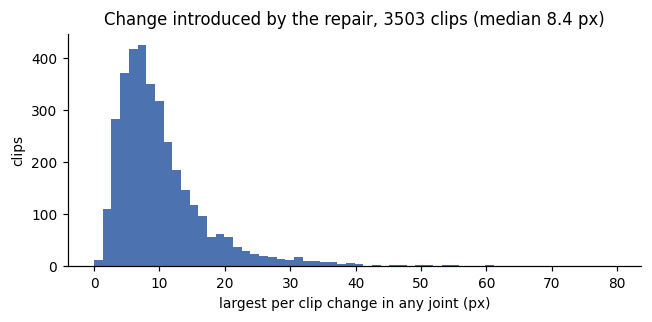

,mode,clips
0,subsampled,4311
1,interpolated,3503


In [11]:
modes = kept["mode"].value_counts().rename_axis("mode").reset_index(name="clips")
publish_table(modes, "repair outcome")

fig, ax = plt.subplots(figsize=(6, 3))
changed = kept.loc[kept["mode"] == "interpolated", "max_abs_diff_vs_old_xy"]
ax.hist(changed, bins=60, color="#4c72b0")
ax.set_xlabel("largest per clip change in any joint (px)")
ax.set_ylabel("clips")
ax.set_title(f"Change introduced by the repair, {len(changed)} clips (median {changed.median():.1f} px)")
fig.tight_layout()
publish(fig, "repair change distribution")
modes

The largest changes come from fast joints (mostly wrists at contact): a duplicated frame sits up to half a real
frame away from where it belongs in time, which is 10 to 20 px for a wrist at full swing speed.

## 5. Pose quality

All remaining sections use the repaired arrays.

In [ ]:
X = np.stack([load("keypoints_interp", r) for _, r in kept.iterrows()])  # (N, 30, 17, 3)
conf = X[..., 2]
print(X.shape, f"finite: {np.isfinite(X).all()}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].bar(JOINTS, conf.mean(axis=(0, 1)), color="#4c72b0")
axes[0].set_ylabel("mean confidence")
axes[1].bar(JOINTS, (conf < 0.3).mean(axis=(0, 1)), color="#c44e52")
axes[1].set_ylabel("share of frames below 0.3")
for ax in axes:
    ax.tick_params(axis="x", rotation=70)
fig.suptitle("RTMPose confidence per joint", fontsize=10)
fig.tight_layout()
publish(fig, "confidence per joint")

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(conf.mean(axis=0).T, aspect="auto", cmap="viridis")
ax.set_yticks(range(17), JOINTS)
ax.set_xlabel("model frame")
ax.set_title("Mean confidence by joint and frame")
fig.colorbar(im, ax=ax, fraction=0.03)
fig.tight_layout()
publish(fig, "confidence by joint and frame")

The wrists are the least reliable joints, and they carry most of the information that separates shot types.
The face joints are also weak, consistent with the near player being filmed from behind.

## 6. Player position, scale and the drill sessions

Li et al. topped up rare classes with controlled ball feeding sessions. Those are the 2023-05-02 recordings.
If they were filmed differently, a model can partly recognise those classes by camera setup rather than by the
stroke.

In [ ]:
hip = X[:, :, [L_HIP, R_HIP], :2].mean(axis=2)                              # (N, 30, 2)
kept["hip_x"], kept["hip_y"] = hip[..., 0].mean(axis=1), hip[..., 1].mean(axis=1)
kept["body_height"] = np.median(X[..., 1].max(axis=2) - X[..., 1].min(axis=2), axis=1)

share = kept.groupby("class_name")["drill"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh([label[c] for c in share.index], share.values, color="#8172b3")
ax.set_xlabel("share of clips from drill sessions")
ax.set_title("Drill session clips per class")
fig.tight_layout()
publish(fig, "drill share per class")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for is_drill, colour, name in [(False, "#4c72b0", "match"), (True, "#c44e52", "drill")]:
    sub = kept[kept["drill"] == is_drill]
    axes[0].scatter(sub["hip_x"], sub["hip_y"], s=3, alpha=0.35, color=colour, label=f"{name} ({len(sub)})")
    axes[1].hist(sub["body_height"], bins=40, density=True, alpha=0.6, color=colour, label=name)
axes[0].set_xlim(0, 1280)
axes[0].set_ylim(960, 0)
axes[0].set_xlabel("mean hip x (px)")
axes[0].set_ylabel("mean hip y (px)")
axes[0].set_title("Player position in frame")
axes[0].legend(frameon=False, markerscale=4)
axes[1].set_xlabel("median body height (px)")
axes[1].set_title("Player scale")
axes[1].legend(frameon=False)
fig.tight_layout()
publish(fig, "drill vs match position and scale")

summary = kept.groupby("drill")[["hip_x", "hip_y", "body_height", "num_frames_total"]].median().round(1)
summary.index = ["match", "drill"]
publish_table(summary.rename_axis("footage").reset_index(), "drill vs match medians")

## 7. How far does a model get without motion?

A random forest trained only on per clip summaries that contain no stroke mechanics: mean court position, body
size and clip length. Whatever it scores is available to any model without learning the shot itself, so it is a
floor for judging what the pose models add.

In [ ]:
train_mask = (kept["split"] == "train") & (kept["n_native"] >= MIN_NATIVE_FRAMES)
test_mask = kept["split"] == "test"
y = kept["class_name"].map({c: i for i, c in enumerate(class_names)}).to_numpy()

probes = {
    "clip length": ["num_frames_total"],
    "position and size": ["hip_x", "hip_y", "body_height"],
    "position, size and length": ["hip_x", "hip_y", "body_height", "num_frames_total"],
    "drill flag": ["drill"],
}
rows = []
for name, cols in probes.items():
    rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=-1)
    rf.fit(kept.loc[train_mask, cols], y[train_mask])
    proba = rf.predict_proba(kept.loc[test_mask, cols])
    pred = rf.classes_[proba.argmax(axis=1)]
    rows.append({"features": name,
                 "top1": accuracy_score(y[test_mask], pred),
                 "top5": top_k_accuracy_score(y[test_mask], proba, k=5, labels=rf.classes_),
                 "mca": balanced_accuracy_score(y[test_mask], pred)})
probe_results = pd.DataFrame(rows).round(4)
for _, r in probe_results.iterrows():
    for m in ["top1", "top5", "mca"]:
        logger.report_single_value(f"probe_{r['features'].replace(', ', '_').replace(' ', '_')}_{m}", r[m])
publish_table(probe_results, "no motion probe (test set)")

Chance is 1/18 (5.6%) and always predicting the largest class gives about 12.7%. Part of what the probe
exploits is legitimate (serves are played from the service line, clears from the rear court) and part is the
drill camera setup. This baseline is reported next to every model, and the input normalisation experiment
tests how much of each the models rely on.

## 8. What the classes look like

One training clip per class, centred on the hips and scaled by body height. Five poses across the clip, with
the right wrist path drawn in full.

In [ ]:
def normalise(clip):
    xy = clip[..., :2]
    centre = xy[:, [L_HIP, R_HIP]].mean(axis=(0, 1))
    height = np.median(xy[..., 1].max(axis=1) - xy[..., 1].min(axis=1))
    return (xy - centre) / height


rng = np.random.RandomState(SEED)
fig, axes = plt.subplots(3, 6, figsize=(13, 7))
cmap = plt.get_cmap("viridis")
for ax, c in zip(axes.flat, class_names):
    pool = kept[(kept["class_name"] == c) & (kept["split"] == "train") & (kept["n_native"] >= 15)]
    pool = pool if len(pool) else kept[kept["class_name"] == c]
    xy = normalise(X[pool.index[rng.randint(len(pool))]])
    for i, t in enumerate(np.linspace(0, 29, 5).astype(int)):
        for a, b in ds.COCO_SKELETON:
            ax.plot(xy[t, [a, b], 0], xy[t, [a, b], 1], color=cmap(i / 4), lw=1.2)
    ax.plot(xy[:, R_WRIST, 0], xy[:, R_WRIST, 1], color="#c44e52", lw=1, ls=":")
    ax.set_title(label[c], fontsize=8)
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.axis("off")
fig.suptitle("One clip per class (colour runs early to late, dotted line: right wrist)", fontsize=10)
fig.tight_layout()
publish(fig, "skeleton per class")

In [ ]:
fig, axes = plt.subplots(3, 6, figsize=(13, 7), sharex=True, sharey=True)
for ax, c in zip(axes.flat, class_names):
    idx = kept.index[(kept["class_name"] == c) & (kept["split"] == "train")]
    for i in rng.choice(idx, size=min(25, len(idx)), replace=False):
        xy = normalise(X[i])
        ax.plot(xy[:, R_WRIST, 0], xy[:, R_WRIST, 1], lw=0.6, alpha=0.5, color="#4c72b0")
    ax.set_title(label[c], fontsize=8)
axes[0, 0].invert_yaxis()
fig.suptitle("Right wrist paths, 25 training clips per class (hip centred, body height units)", fontsize=10)
fig.tight_layout()
publish(fig, "right wrist paths per class")

## 9. Summary

Cleaning decisions carried into every model notebook.

In [ ]:
decisions = pd.DataFrame([
    {"step": "manual review exclusion", "rule": "unusable occlusion or wrong player", "clips": len(excluded), "splits": "all"},
    {"step": "resampling repair", "rule": "real frames recovered, smoothed at 60 fps, interpolated to 30",
     "clips": int((kept["mode"] == "interpolated").sum()), "splits": "all"},
    {"step": "short clip rule", "rule": f"fewer than {MIN_NATIVE_FRAMES} real frames", "clips": len(dropped), "splits": "train only"},
])
publish_table(decisions, "cleaning decisions")

task.upload_artifact("repair_log", artifact_object=f"{DATA}/keypoints_interp_log.csv")
task.upload_artifact("train_clips_dropped", artifact_object=dropped[["filepath", "n_native"]])
task.upload_artifact("no_motion_probe", artifact_object=probe_results)
decisions

In [ ]:
task.close()